In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import random

# Set seed
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Set all text weights and sizes to 14 Bold globally
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Ensure individual components inherit the bold styling and size
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

# Apply bold to axis tick numbers
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Task-1: Load CIFAR

In [ ]:
import torchvision
import torchvision.transforms as transforms
from collections import Counter

# Load Dataset
transform = transforms.ToTensor()
train_set = torchvision.datasets.CIFAR10(root='./datasets', train=True, download=True, transform=transform)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
# 2. Print Dataset Dimensions
print(f"Total Samples: {len(train_set)}")
print(f"Raw Image Shape: {train_set.data.shape[1:]}")
print(f"Tensor Shape: {train_set[0][0].shape}")

Total Samples: 50000
Raw Image Shape: (32, 32, 3)
Tensor Shape: torch.Size([3, 32, 32])


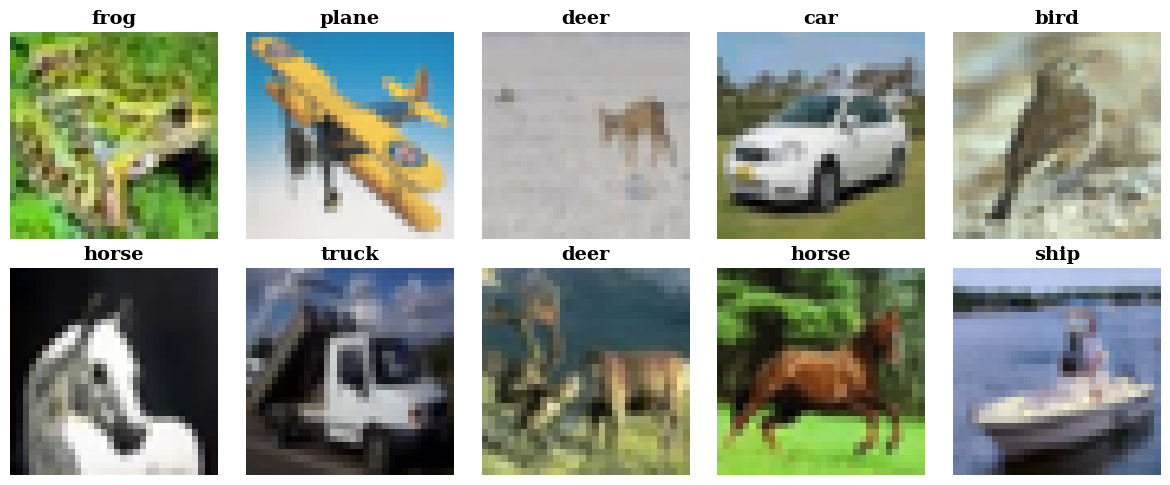

In [ ]:
# 3. Display 10 Sample Images
loader = torch.utils.data.DataLoader(train_set, batch_size=10, shuffle=True)
images, labels = next(iter(loader))

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Permute converts PyTorch tensor (C, H, W) -> Matplotlib image format (H, W, C)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.savefig('cifar_sample_images.eps', format='eps', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

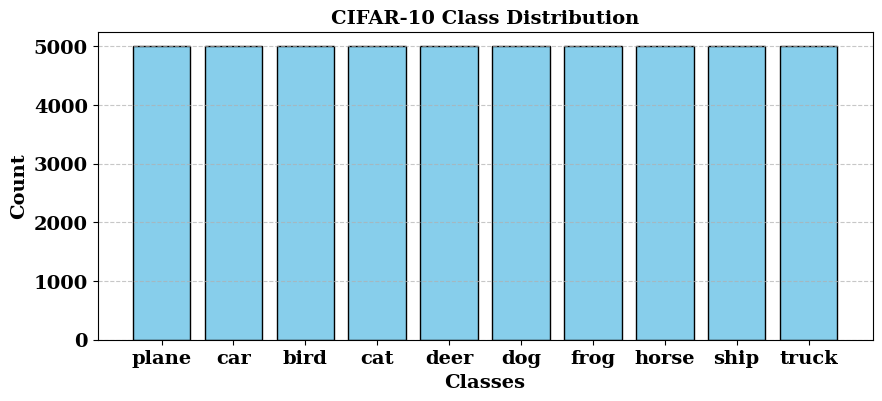

In [ ]:
# 4. Plot Class Distribution
counts = Counter(train_set.targets)

plt.figure(figsize=(10, 4))
plt.bar(classes, [counts[i] for i in range(10)], color='skyblue', edgecolor='black')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('CIFAR-10 Class Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('cifar_class_dist.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Task-2

In [ ]:
import torch.nn as nn

# Load a sample image from CIFAR-10
transform = transforms.ToTensor()
train_set = torchvision.datasets.CIFAR10(root='./datasets', train=True, download=True, transform=transform)
sample_tensor = train_set[0][0].unsqueeze(0)

kernel_sizes = [3, 5, 7]
print(f"Input Shape: {list(sample_tensor.shape)}\n")

for k in kernel_sizes:
    conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=k, stride=1, padding=0)
    output = conv(sample_tensor)
    print(f"Kernel Size: {k}x{k} -> Output Shape: {list(output.shape)} -> Feature Map Size: {output.shape[2:]}")

Input Shape: [1, 3, 32, 32]

Kernel Size: 3x3 -> Output Shape: [1, 16, 30, 30] -> Feature Map Size: torch.Size([30, 30])
Kernel Size: 5x5 -> Output Shape: [1, 16, 28, 28] -> Feature Map Size: torch.Size([28, 28])
Kernel Size: 7x7 -> Output Shape: [1, 16, 26, 26] -> Feature Map Size: torch.Size([26, 26])


In [ ]:
# Fixed kernel size of 3x3 for comparison
print(f"Base Input Shape: {list(sample_tensor.shape)}\n")

# 1. Compare Stride (with valid/zero padding)
conv_s1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)
conv_s2 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=0)
print(f"Stride = 1 (Padding=0): Output Shape = {list(conv_s1(sample_tensor).shape)}")
print(f"Stride = 2 (Padding=0): Output Shape = {list(conv_s2(sample_tensor).shape)}")

# 2. Compare Padding (with stride 1)
conv_valid = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)       # Valid = no padding
conv_same  = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding='same')  # Same = keeps spatial dim
print(f"Padding = Valid (0)  : Output Shape = {list(conv_valid(sample_tensor).shape)}")
print(f"Padding = Same       : Output Shape = {list(conv_same(sample_tensor).shape)}")

Base Input Shape: [1, 3, 32, 32]

Stride = 1 (Padding=0): Output Shape = [1, 16, 30, 30]
Stride = 2 (Padding=0): Output Shape = [1, 16, 15, 15]
Padding = Valid (0)  : Output Shape = [1, 16, 30, 30]
Padding = Same       : Output Shape = [1, 16, 32, 32]


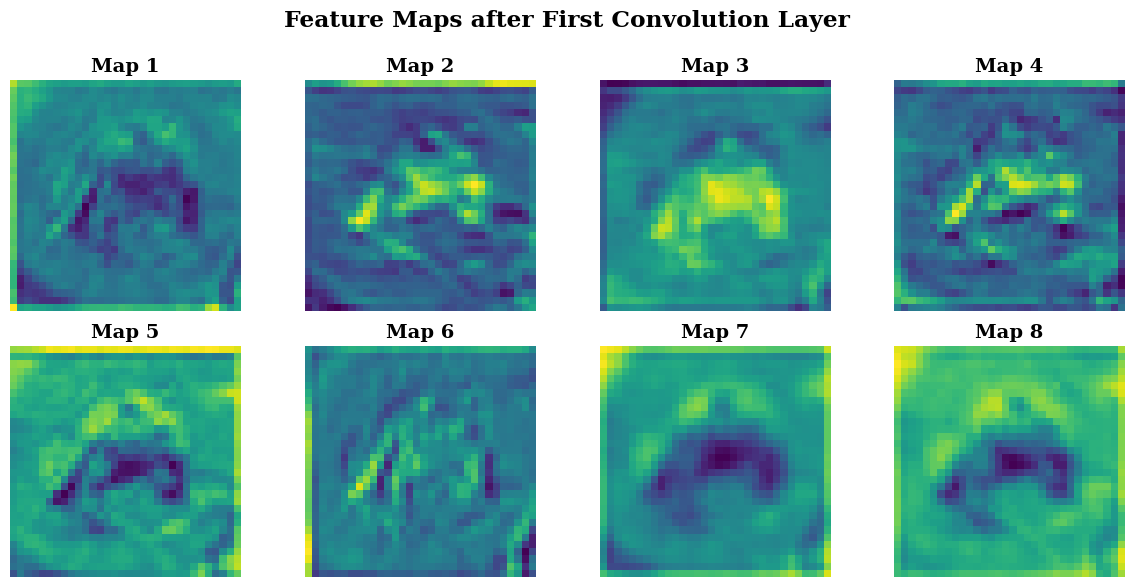

In [ ]:
import matplotlib.pyplot as plt

# Extract 1st conv layer outputs
conv_layer = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)
with torch.no_grad():
    feature_maps = conv_layer(sample_tensor).squeeze(0) # Shape: [8, 32, 32]

# Plotting the 8 feature maps
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[i].numpy(), cmap='viridis')
    plt.title(f"Map {i+1}")
    plt.axis('off')
plt.suptitle("Feature Maps after First Convolution Layer")
plt.savefig('feature_maps.eps', format='eps', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader

# Check Output Sizes directly
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
dummy_feature_map = torch.randn(1, 16, 30, 30)

print(f"Input Feature Map Shape: {list(dummy_feature_map.shape)}")
print(f"Max Pooling Output Shape: {list(max_pool(dummy_feature_map).shape)}")
print(f"Avg Pooling Output Shape: {list(avg_pool(dummy_feature_map).shape)}\n")

Input Feature Map Shape: [1, 16, 30, 30]
Max Pooling Output Shape: [1, 16, 15, 15]
Avg Pooling Output Shape: [1, 16, 15, 15]



In [ ]:
# Setup data loaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_set = torchvision.datasets.CIFAR10(root='./datasets', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

# Define the Architecture
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Input: [32, 3, 32, 32]
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # [32, 32, 32, 32]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # [32, 32, 16, 16]
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [32, 64, 16, 16]
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # [32, 64, 8, 8]
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 10) # Softmax embedded implicitly in PyTorch's CrossEntropyLoss
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Metric logs for mandatory plotting
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# Training Loop
for epoch in range(20):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    # Validation metrics
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(test_loader.dataset)
    epoch_val_acc = val_correct / val_total

    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/20 | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f}")

Epoch 1/20 | Train Loss: 1.4831 Acc: 0.4741 | Val Loss: 1.2045 Val Acc: 0.5780
Epoch 2/20 | Train Loss: 1.1275 Acc: 0.6071 | Val Loss: 1.0696 Val Acc: 0.6272
Epoch 3/20 | Train Loss: 0.9932 Acc: 0.6561 | Val Loss: 1.0281 Val Acc: 0.6400
Epoch 4/20 | Train Loss: 0.9156 Acc: 0.6824 | Val Loss: 0.9381 Val Acc: 0.6768
Epoch 5/20 | Train Loss: 0.8622 Acc: 0.7025 | Val Loss: 0.9337 Val Acc: 0.6792
Epoch 6/20 | Train Loss: 0.8213 Acc: 0.7152 | Val Loss: 0.8990 Val Acc: 0.6910
Epoch 7/20 | Train Loss: 0.7845 Acc: 0.7273 | Val Loss: 0.8951 Val Acc: 0.6901
Epoch 8/20 | Train Loss: 0.7542 Acc: 0.7377 | Val Loss: 0.9009 Val Acc: 0.6904
Epoch 9/20 | Train Loss: 0.7241 Acc: 0.7479 | Val Loss: 0.8888 Val Acc: 0.6936
Epoch 10/20 | Train Loss: 0.6985 Acc: 0.7571 | Val Loss: 0.9008 Val Acc: 0.7004
Epoch 11/20 | Train Loss: 0.6758 Acc: 0.7648 | Val Loss: 0.9214 Val Acc: 0.6909
Epoch 12/20 | Train Loss: 0.6536 Acc: 0.7744 | Val Loss: 0.9231 Val Acc: 0.6901
Epoch 13/20 | Train Loss: 0.6380 Acc: 0.7795 | Va

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculations
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
cm = confusion_matrix(all_labels, all_preds)

print("=== Classification Metrics ===")
print(f"Accuracy:  {history['val_acc'][-1]:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")
print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=classes))

=== Classification Metrics ===
Accuracy:  0.6984
Precision: 0.7006
Recall:    0.6984
F1-Score:  0.6984

=== Classification Report ===
              precision    recall  f1-score   support

       plane       0.74      0.70      0.72      1000
         car       0.82      0.79      0.81      1000
        bird       0.57      0.63      0.60      1000
         cat       0.50      0.50      0.50      1000
        deer       0.65      0.68      0.66      1000
         dog       0.64      0.58      0.61      1000
        frog       0.82      0.71      0.76      1000
       horse       0.73      0.77      0.75      1000
        ship       0.79      0.80      0.80      1000
       truck       0.74      0.82      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



# Plots

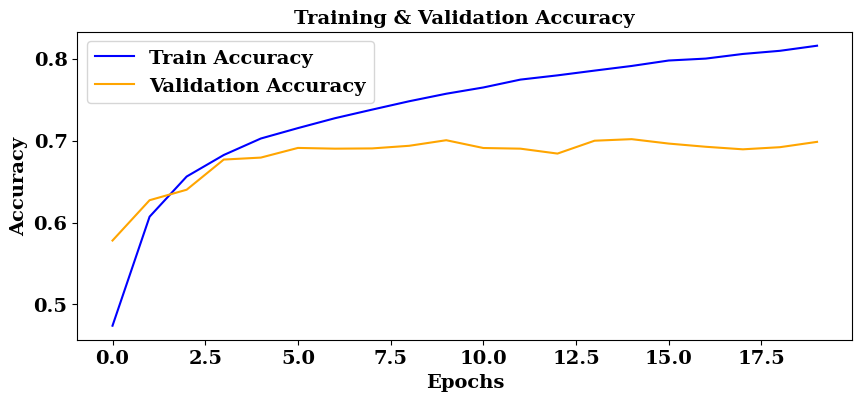

In [ ]:
import seaborn as sns
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 1. & 2. Sample Images and Distribution Plots (Generated during Task 1)
# 3. & 4. Accuracy Plots
plt.figure(figsize=(10, 4))
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('train_val_accuracy.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

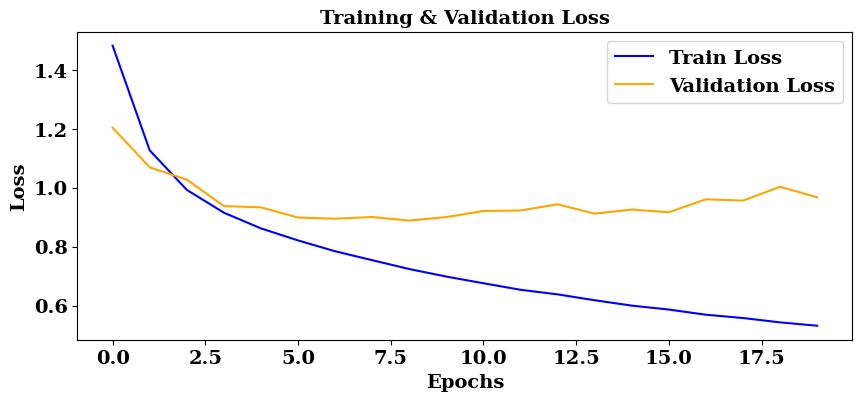

In [ ]:
# 5. & 6. Loss Plots
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('train_val_loss.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

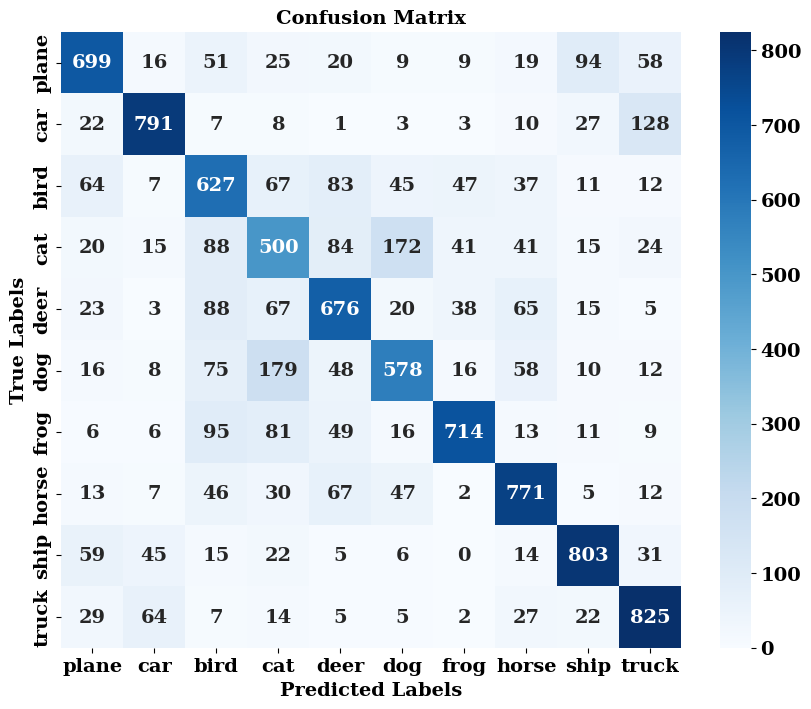

In [ ]:
# 8. Confusion Matrix Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.savefig('confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()